# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть хочет выделить клиентские сегменты и использовать SMS-рассылки для стимулирования повторных покупок и роста выручки.

### Цели исследования

- выделить клиентские сегменты по поведению покупателей;
- определить, какие сегменты приносят основную выручку;
- предложить практические рекомендации по удержанию и реактивации клиентов.

### Бизнес-контекст

Проект помогает понять, какие клиенты приносят основную выручку, кого важно удерживать в первую очередь и какие сегменты можно возвращать недорогими коммуникациями.

### Структура данных

Для анализа использовалась таблица транзакций по бонусным картам. В работу включались только те покупки, где клиент мог быть идентифицирован по карте. Это важно, потому что офлайн-операции без привязки к карте не дают возможности корректно оценить поведение клиента.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

### Подключение к данным

In [42]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

Для дальнейшего удобства сразу напишем настройки для графиков и вспомогательные методы

In [43]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [44]:
def draw_bar(df, x_col, y_col, title, xlabel, ylabel, format_labels=None):
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=x_col,
        palette="deep",
        legend=False
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=35, ha="right")

    for container in ax.containers:
        if format_labels == "currency":
            labels = [f"{value:,.0f}" for value in container.datavalues]
        else:
            labels = [f"{value:,.0f}" for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

    plt.tight_layout()
    plt.show()

In [45]:
def read_sql_from_file(filename):
    query = Path(f"sql/{filename}.sql").read_text(encoding="utf-8")
    return pd.read_sql(text(query), engine)

### RFM-сегментация клиентов

RFM-анализ позволяет разделить клиентов по трем измерениям: давности последней покупки, частоте покупок и сумме трат. Это помогает понять, где у компании активная база, а где — клиенты с высоким риском оттока.

Посмотрим на результат SQL запроса и визуализируем его

In [46]:
rfm_df = read_sql_from_file("rfm_segmentation")
rfm_df

,segment,customers,total_customers,total_revenue_per_segment,customer_share_pct
0,Лояльные,2135,5926.0,6240110.0,36.03
1,Потерянные,1176,5926.0,702923.0,19.84
2,Чемпионы,964,5926.0,10371849.0,16.27
3,Под угрозой,849,5926.0,1027741.0,14.33
4,Нельзя терять,802,5926.0,854217.0,13.53


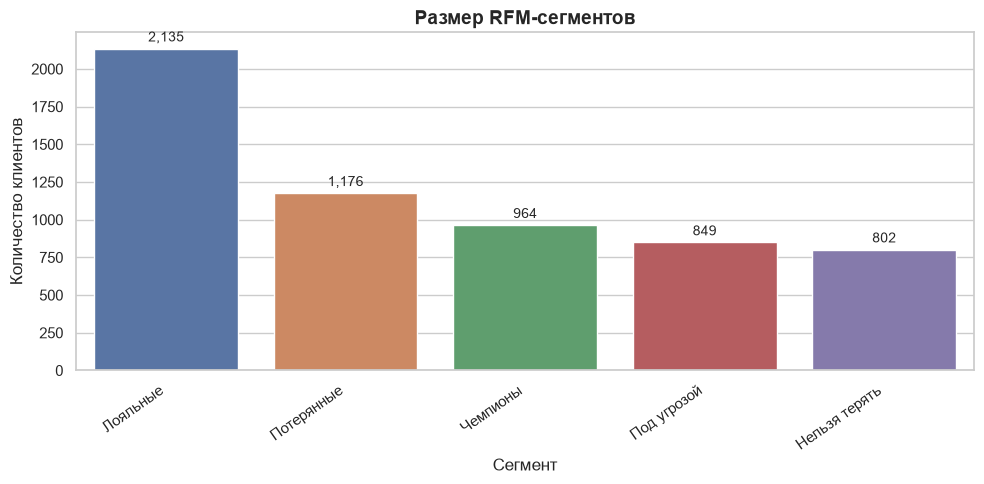

In [47]:
draw_bar(
    rfm_df,
    x_col='segment',
    y_col='customers',
    title='Размер RFM-сегментов',
    xlabel='Сегмент',
    ylabel='Количество клиентов'
)

#### Вывод

В базе есть как активные и лояльные клиенты, так и группы с высоким риском оттока. Это означает, что рост выручки можно обеспечивать не только за счет привлечения новых клиентов, но и за счет работы с уже существующей аудиторией.

#### Общая выручка по сегменту

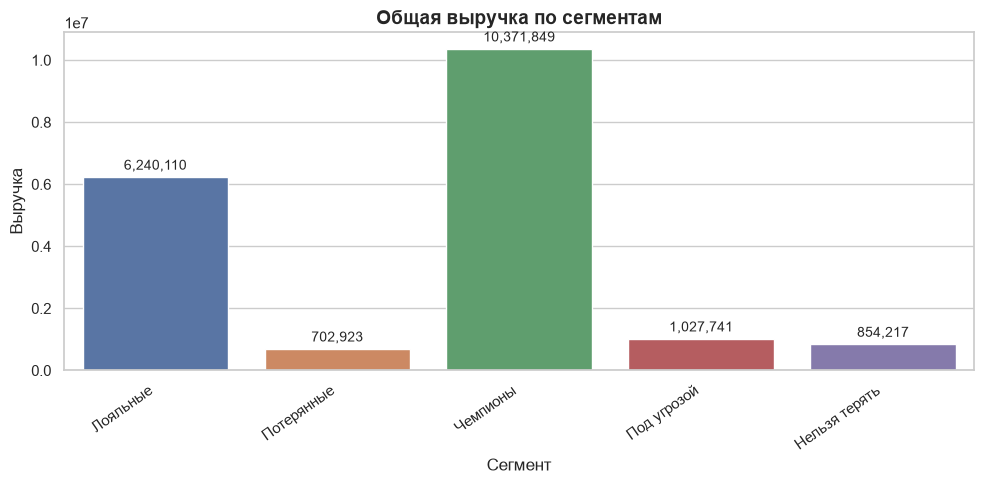

In [48]:
draw_bar(
    rfm_df,
    x_col='segment',
    y_col='total_revenue_per_segment',
    title='Общая выручка по сегментам',
    xlabel='Сегмент',
    ylabel='Выручка'
)

#### Вывод

Сегмент 'Чемпионы' приносит максимальную выручку. Это ядро клиентской базы, и именно ему стоит отдавать первоочередное внимание.

### ABC-анализ

RFM показывает поведение клиента, но не всегда отражает его реальную ценность для бизнеса. Чтобы понять, какие клиенты приносят основную выручку, добавим ABC-анализ.

In [49]:
abc_rfm_df = read_sql_from_file("abc_revenue")
abc_rfm_df = abc_rfm_df[["card", "segment", "abc_revenue", "total_revenue", "cum_revenue_pct"]]
abc_rfm_df.head()

,card,segment,abc_revenue,total_revenue,cum_revenue_pct
0,2000200170860,Чемпионы,A,163943,0.85
1,2000200196556,Чемпионы,A,122941,1.49
2,2000200196600,Чемпионы,A,120782,2.12
3,2000200189985,Чемпионы,A,112173,2.71
4,2000200204541,Чемпионы,A,102314,3.24


In [50]:
abc_summary = (
    abc_rfm_df.groupby('abc_revenue')
    .agg(customers=('card', 'count'), revenue=('total_revenue', 'sum'))
    .reset_index()
)

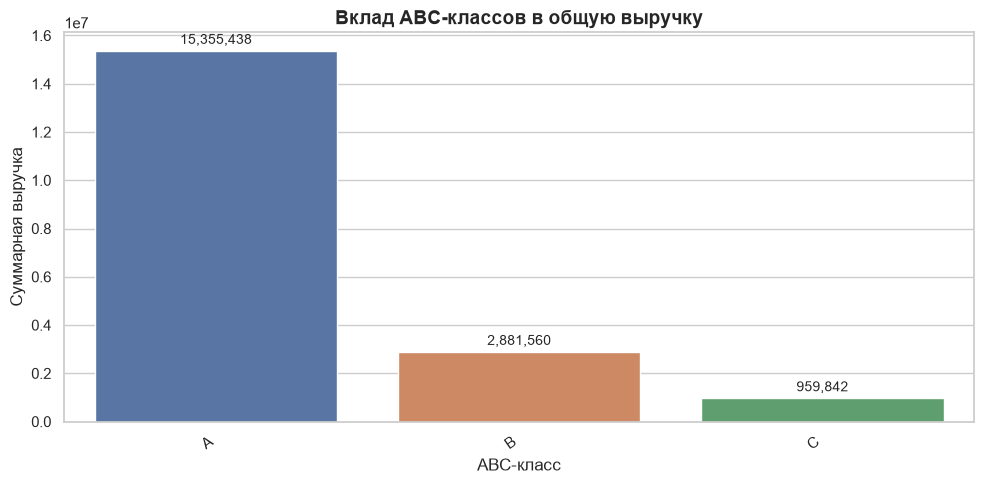

In [51]:
draw_bar(
    abc_summary,
    x_col='abc_revenue',
    y_col='revenue',
    title='Вклад ABC-классов в общую выручку',
    xlabel='ABC-класс',
    ylabel='Суммарная выручка',
    format_labels='currency'
)

#### Вывод

Класс A формирует основную часть выручки. Это ключевая группа для бизнеса, и именно ее следует держать под особым контролем.

### Распределение клиентов по RFM-сегментам и ABC-классам

In [52]:
rfm_abc = (
    abc_rfm_df.groupby(['segment', 'abc_revenue'])
    .agg(customers=('card', 'count'))
    .reset_index()
)

pivot = rfm_abc.pivot(index='segment', columns='abc_revenue', values='customers').fillna(0)

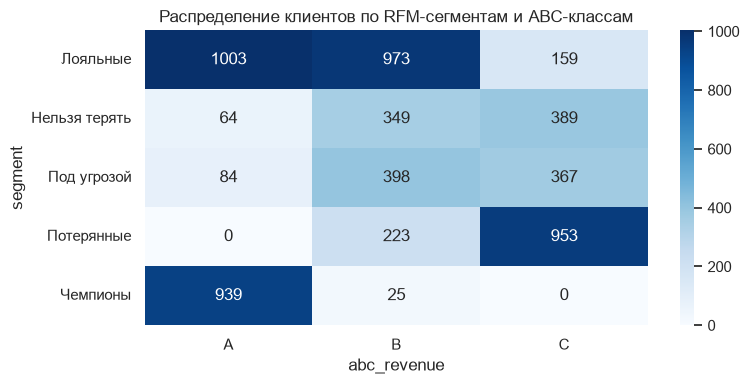

In [53]:
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Распределение клиентов по RFM-сегментам и ABC-классам')
plt.tight_layout()
plt.show()

RFM показывает поведение клиента, а ABC — его вклад в выручку. Вместе они позволяют выделить не просто «активных» и «неактивных», а действительно ценных клиентов и тех, кого стоит вернуть в активную покупку.

## Рекомендации по сегментам

Ниже — управленческий взгляд на результат анализа. Сегменты объединены по схожей стратегии, чтобы было проще выбирать действия.

| Сегмент | ABC-класс | Приоритет | Рекомендация |
| --- | --- | --- | --- |
| Чемпионы | A | Удержание | Персональные условия, VIP-предложения, бонусы за повторные покупки и ранний доступ к новинкам. |
| Лояльные | A/B | Развитие | Кросс-продажи, рекомендации по смежным товарам и программы для роста среднего чека. |
| Под угрозой | A/B | Реактивация | Целевые бонусы, напоминания о повторной покупке и персонализированные предложения для возврата в активное состояние. |
| Нельзя терять | A | Приоритетная win-back | Индивидуальные коммуникации, специальные условия и быстрый контакт с клиентом для предотвращения потери выручки. |
| Потерянные | B/C | Тестирование | Низкобюджетные win-back кампании с осторожным подходом и оценкой эффективности. |

**Ключевая мысль:** не все сегменты требуют одинакового уровня внимания. Наиболее ценные клиенты должны получать более сильные и персонализированные коммуникации, а менее активные — более осторожные и экономичные действия.